<a href="https://colab.research.google.com/github/AncaraniJuanDiego/IAModelosDeRegresi-n./blob/main/RedNeuronal_AnatomiaCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Juan Diego Ancarani

# TP: Anatomía de una CNN con Fashion-MNIST  
## Notebook esqueleto para completar

Notebook completo para estudiar la anatomía de una red neuronal convolucional (CNN), desde la carga y preprocesamiento de imágenes hasta la evaluación y análisis de errores.

**Objetivo** → Construir una CNN para clasificar las 10 categorías de Fashion-MNIST.

In [ ]:
#Importaciones y configuración

# =============================================================================
# TP: Anatomía de una CNN con Fashion-MNIST
# =============================================================================

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Librería opcional para métricas por clase
from sklearn.metrics import classification_report, confusion_matrix

# Semillas para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


In [ ]:
# -----------------------------------------------------------------------------
# 1. Carga del dataset Fashion-MNIST
# -----------------------------------------------------------------------------

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [ ]:
# -----------------------------------------------------------------------------
# 2. Preprocesamiento de las imágenes
# -----------------------------------------------------------------------------

# Agregamos la dimensión de canal:
# (cantidad, 28, 28) -> (cantidad, 28, 28, 1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("x_train shape con canal:", x_train.shape)
print("x_test shape con canal:", x_test.shape)
print("Rango de x_train:", x_train.min(), "a", x_train.max())

# Nombres de las clases
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


x_train shape con canal: (60000, 28, 28, 1)
x_test shape con canal: (10000, 28, 28, 1)
Rango de x_train: 0.0 a 1.0


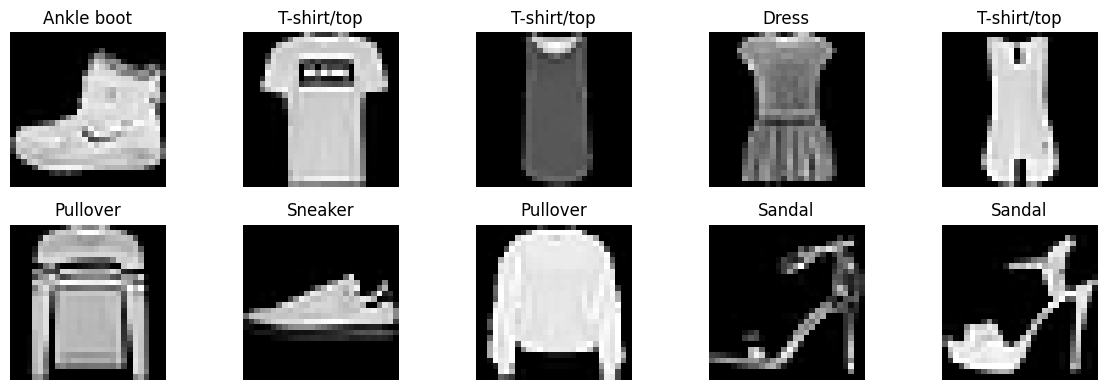

In [ ]:
# -----------------------------------------------------------------------------
# 3. Visualización de ejemplos del dataset
# -----------------------------------------------------------------------------

plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


### 4. Construcción del modelo CNN

* La arquitectura elegida es:

Entrada → Conv2D(32) → MaxPooling → Conv2D(64) → MaxPooling → Dropout → Flatten → Dense(128) → Softmax(10)

La primera convolución aprende características locales simples. La segunda puede combinar esas características para representar patrones más complejos.

In [ ]:
# -----------------------------------------------------------------------------
# 4. Construcción del modelo CNN
# -----------------------------------------------------------------------------

model = models.Sequential([
    # Entrada + primera convolución
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),

    # Reduce el tamaño espacial
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Segunda convolución: aprende características más complejas
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    # Segundo pooling
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Regularización
    layers.Dropout(0.30),

    # Pasa de mapas 2D a vector
    layers.Flatten(),

    # Capa densa intermedia
    layers.Dense(128, activation="relu"),

    # 10 clases de Fashion-MNIST
    layers.Dense(10, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# -----------------------------------------------------------------------------
# 5. Compilación del modelo
# -----------------------------------------------------------------------------

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Modelo compilado correctamente.")


Modelo compilado correctamente.


In [ ]:
# -----------------------------------------------------------------------------
# 6. Entrenamiento del modelo
# -----------------------------------------------------------------------------

history = model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 55ms/step - accuracy: 0.8072 - loss: 0.5321 - val_accuracy: 0.8560 - val_loss: 0.4158
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.8678 - loss: 0.3645 - val_accuracy: 0.8792 - val_loss: 0.3429
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.8847 - loss: 0.3138 - val_accuracy: 0.8898 - val_loss: 0.3075
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - accuracy: 0.8972 - loss: 0.2800 - val_accuracy: 0.8992 - val_loss: 0.2796
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 79s 55ms/step - accuracy: 0.9055 - loss: 0.2562 - val_accuracy: 0.9033 - val_loss: 0.2745
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 57ms/step - accuracy: 0.9124 - loss: 0.2361 - val_accuracy: 0.9062 - val_loss: 0.2603
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 55ms/step - accuracy: 0.9176 - loss: 0.2224 - val_accuracy: 0.9063 - val_loss: 0.2690
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9220 - loss: 0.2078 - 

In [ ]:
# -----------------------------------------------------------------------------
# 7. Evaluación en el conjunto de test
# -----------------------------------------------------------------------------

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


Test loss: 0.2707
Test accuracy: 0.9106


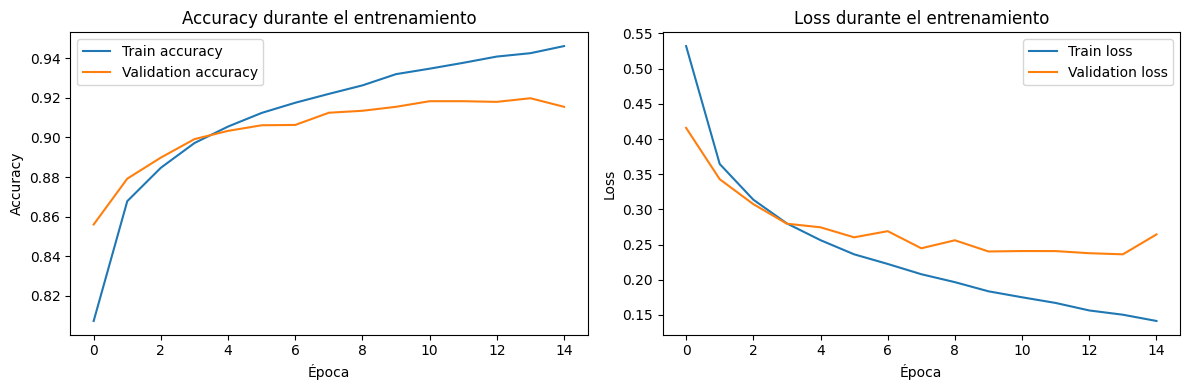

In [ ]:
# -----------------------------------------------------------------------------
# 8. Visualización de curvas de entrenamiento
# -----------------------------------------------------------------------------

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Accuracy durante el entrenamiento")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss durante el entrenamiento")
plt.legend()

plt.tight_layout()
plt.show()


Predicciones correctas: 9106
Predicciones incorrectas: 894
Accuracy calculado: 0.9106


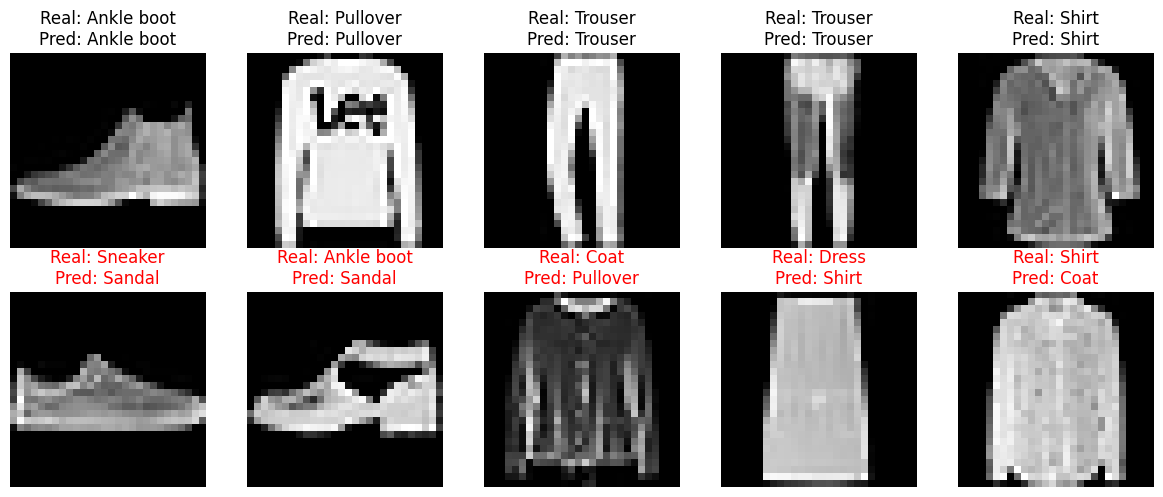

In [ ]:
# -----------------------------------------------------------------------------
# 9. Predicciones y análisis de errores
# -----------------------------------------------------------------------------

# Probabilidades para cada una de las 10 clases
y_pred_proba = model.predict(x_test, verbose=0)

# Clase con mayor probabilidad
y_pred = np.argmax(y_pred_proba, axis=1)

# Máscaras de correctas e incorrectas
correct = (y_pred == y_test)
incorrect = (y_pred != y_test)

print("Predicciones correctas:", correct.sum())
print("Predicciones incorrectas:", incorrect.sum())
print("Accuracy calculado:", correct.mean())

# Visualizar 5 correctas y 5 incorrectas
plt.figure(figsize=(12, 5))

# 5 correctas
correct_indices = np.where(correct)[0][:5]
for i, idx in enumerate(correct_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap="gray")
    plt.title(
        f"Real: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}"
    )
    plt.axis("off")

# 5 incorrectas
incorrect_indices = np.where(incorrect)[0][:5]
for i, idx in enumerate(incorrect_indices):
    plt.subplot(2, 5, i + 6)
    plt.imshow(x_test[idx].squeeze(), cmap="gray")
    plt.title(
        f"Real: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}",
        color="red"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


## **A. Sobre la arquitectura**

¿Cuántas capas entrenables tiene tu modelo?
La arquitectura tiene 4 capas entrenables:

1. Conv2D(32, 3×3)
2. Conv2D(64, 3×3)
3. Dense(128)
4. Dense(10)

No contamos MaxPooling2D, Dropout ni Flatten porque no tienen parámetros entrenables.

¿Cuál es la cantidad total de parámetros entrenables?
Usar model.summary() y copiar el valor de Total params.

Para esta arquitectura, el cálculo es:
- Primera Conv2D: (3×3×1 + 1) × 32 = 320
- Segunda Conv2D: (3×3×32 + 1) × 64 = 18.496
- Dense(128): (3×3×64 + 1) × 128 = 73.856
- Dense(10): (128 + 1) × 10 = 1.290
Total = 93.962 parámetros entrenables.

¿Qué hace cada capa?

- Conv2D: aplica filtros/kernels que recorren la imagen y aprenden características locales como bordes, texturas y formas.
- MaxPooling2D: reduce el tamaño espacial de los mapas de características, conservando las activaciones más importantes de cada región.
- Dropout: durante el entrenamiento desactiva aleatoriamente una proporción de unidades para ayudar a reducir el sobreajuste.
- Flatten: transforma los mapas de características en un vector para poder conectarlos con las capas Dense.
- Dense final: produce 10 valores de salida, uno por cada clase, y softmax los convierte en probabilidades que suman 1.

¿Por qué la última capa tiene 10 unidades y softmax?

Fashion-MNIST tiene 10 clases, por lo que la salida necesita 10 valores.

softmax transforma esos valores en probabilidades. La clase predicha es la que tiene la probabilidad más alta.

------------------------------


### **B. Sobre el entrenamiento**

5. Interpretación de las curvas

Al ejecutar el notebook, observar:

- Si train accuracy aumenta, la red está aprendiendo sobre los datos de entrenamiento.
- Si val accuracy también aumenta, el aprendizaje se está generalizando a datos de validación.
- Si train loss continúa bajando mientras val loss comienza a subir, aparece una señal de overfitting.
La comparación entre entrenamiento y validación es más importante que mirar solamente el rendimiento de entrenamiento.

6. ¿Cómo reducir el sobreajuste?

Algunas posibilidades son:

- aumentar Dropout;
- reducir la cantidad de filtros o neuronas;
- utilizar EarlyStopping;
- aplicar data augmentation;
- reducir la complejidad de la arquitectura;
- ajustar el número de épocas.

La elección debe comprobarse comparando las métricas de validación y test.

----------------------------------------

### **C. Resultado sobre las predicciones**

**7. Análisis de errores**

Al observar las imágenes incorrectas, prestar especial atención a las clases visualmente parecidas.

En Fashion-MNIST es esperable encontrar confusiones entre algunas prendas de aspecto similar, por ejemplo Shirt, T-shirt/top, Pullover y Coat.

Una posible explicación es que las imágenes son pequeñas (28×28 píxeles), están en escala de grises y algunas categorías presentan formas visualmente similares.

La respuesta final debe basarse en las imágenes que produzca tu ejecución.

**8. Precisión por clase**

La siguiente celda permite obtener precision, recall y F1-score para cada clase.

In [ ]:
#10. Reporte de clasificación por clase

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))


              precision    recall  f1-score   support

 T-shirt/top       0.83      0.88      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.84      0.90      0.87      1000
       Dress       0.90      0.93      0.91      1000
        Coat       0.83      0.89      0.86      1000
      Sandal       0.97      0.99      0.98      1000
       Shirt       0.82      0.65      0.73      1000
     Sneaker       0.93      0.99      0.96      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.99      0.93      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



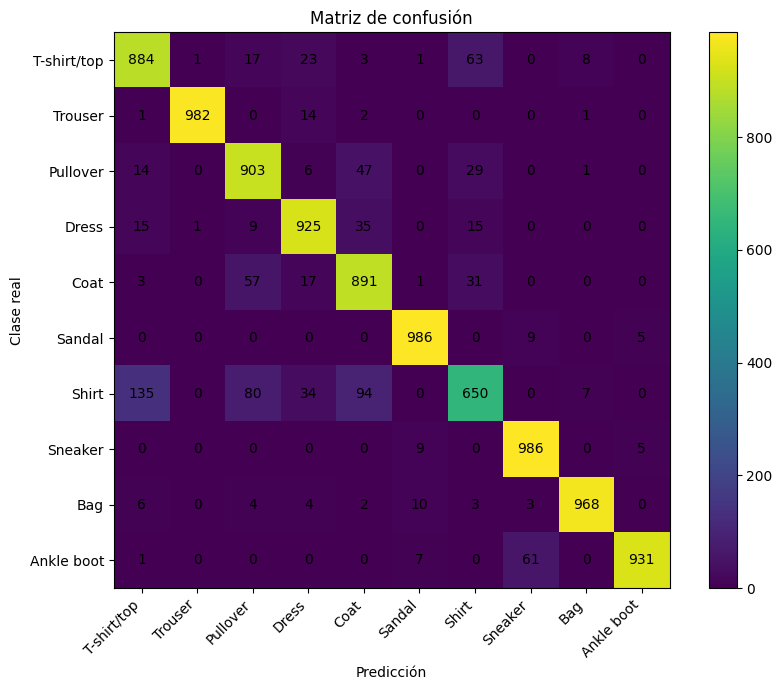

In [ ]:
#11. Matriz de confusión

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
plt.imshow(cm)
plt.colorbar()
plt.xticks(range(10), class_names, rotation=45, ha="right")
plt.yticks(range(10), class_names)
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de confusión")

# Escribir los valores dentro de las celdas
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


## **D. Experimentación**

Como variante se agrega un tercer bloque Conv2D + MaxPooling2D y se incrementan los filtros progresivamente:

[32 → 64 → 128]

Esto aumenta la capacidad de la red para aprender representaciones más complejas, pero también aumenta la cantidad de parámetros y el riesgo de sobreajuste.

In [ ]:
# -----------------------------------------------------------------------------
#12. Modelo modificado: una tercera Conv2D + MaxPooling2D
# -----------------------------------------------------------------------------

model_v2 = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Nuevo bloque convolucional
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Dropout(0.30),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_v2.summary()

model_v2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_v2 = model_v2.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

test_loss_v2, test_acc_v2 = model_v2.evaluate(
    x_test, y_test, verbose=0
)

print(f"Test accuracy (modelo modificado): {test_acc_v2:.4f}")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,474 (431.54 KB)

 Trainable params: 110,474 (431.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 74s 82ms/step - accuracy: 0.7444 - loss: 0.6929 - val_accuracy: 0.8107 - val_loss: 0.5286
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 74s 73ms/step - accuracy: 0.8264 - loss: 0.4763 - val_accuracy: 0.8350 - val_loss: 0.4472
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 76s 65ms/step - accuracy: 0.8484 - loss: 0.4147 - val_accuracy: 0.8492 - val_loss: 0.4033
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 85s 69ms/step - accuracy: 0.8622 - loss: 0.3751 - val_accuracy: 0.8670 - val_loss: 0.3495
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 60s 72ms/step - accuracy: 0.8729 - loss: 0.3455 - val_accuracy: 0.8733 - val_loss: 0.3345
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 66s 78ms/step - accuracy: 0.8814 - loss: 0.3234 - val_accuracy: 0.8782 - val_loss: 0.3221
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 56s 67ms/step - accuracy: 0.8871 - loss: 0.3049 - val_accuracy: 0.8823 - val_loss: 0.3122
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 75s 59ms/step - accuracy: 0.8932 - loss: 0.2884 - 

In [ ]:
#13. Comparación de modelos.

print(f"Modelo original - Test accuracy: {test_acc:.4f}")
print(f"Modelo v2       - Test accuracy: {test_acc_v2:.4f}")

if test_acc_v2 > test_acc:
    print("La accuracy del modelo v2 fue mayor en este experimento.")
elif test_acc_v2 < test_acc:
    print("La accuracy del modelo v2 fue menor en este experimento.")
else:
    print("Ambos modelos obtuvieron la misma accuracy.")


Modelo original - Test accuracy: 0.9106
Modelo v2       - Test accuracy: 0.8957
La accuracy del modelo v2 fue menor en este experimento.


## **Conclusión**

* La CNN utiliza la convolución para trabajar directamente sobre la estructura espacial de la imagen.

A diferencia del MLP, no necesita tratar los 784 píxeles de una imagen 28×28 como una lista completamente independiente: los filtros recorren regiones locales y comparten sus pesos en distintas posiciones.

**Las principales ideas observadas en este TP son:**

- Conv2D: extracción de características mediante kernels aprendidos.
- Stride: controla cuánto se desplaza el kernel.
- Padding: controla el tratamiento de los bordes y el tamaño espacial.
- MaxPooling: reduce dimensiones y conserva activaciones relevantes.
- Dropout: ayuda a controlar el overfitting.
- Flatten: conecta la representación convolucional con las capas Dense.
- Softmax: produce probabilidades para las 10 clases.
- Validation/Test: permiten evaluar la capacidad de generalización.

Finalmente, la arquitectura no debe juzgarse solamente por su accuracy de entrenamiento: interesa especialmente cómo se comporta sobre datos que no utilizó directamente para ajustar sus pesos.